Khmer Abstractive Summarization - Research-Grade Training Pipeline \
Hardware: NVIDIA L4 GPU \
Framework: PyTorch + Hugging Face Transformers 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import sentencepiece as spm
from pathlib import Path
import json
import os
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

c:\Users\limse\miniconda3\envs\py311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Memory: 8.59 GB


Comprehensive configuration for all training aspects \
Modify these parameters based on your dataset and resources

In [2]:
class Config:
    # Paths
    DATA_PATH = "KhmerTimes-Summary-Latest.csv"  # Your CSV with Article, Summary columns
    OUTPUT_DIR = "khmer_summarizer_output"
    TOKENIZER_PATH = "khmer_tokenizer"
    
    # Tokenizer
    VOCAB_SIZE = 32000
    CHARACTER_COVERAGE = 1.0  # Critical for Khmer Unicode
    
    # Model Architecture
    ENCODER_MODEL = "xlm-roberta-base"  # 270M params, good multilingual Khmer
    HIDDEN_SIZE = 768
    DECODER_LAYERS = 6
    DECODER_HEADS = 12
    DECODER_INTERMEDIATE = 3072
    DROPOUT = 0.1
    
    # Pointer-Generator
    USE_POINTER = False  # Enable copying mechanism
    
    # Training
    BATCH_SIZE = 12  # Adjust based on L4 memory
    GRAD_ACCUMULATION = 4  # Effective batch size = 32
    LEARNING_RATE = 5e-6
    ENCODER_LR = 1e-6  # Lower for pretrained encoder
    WARMUP_RATIO = 0.3
    NUM_EPOCHS = 10
    MAX_GRAD_NORM = 0.3
    LABEL_SMOOTHING = 0.0
    WEIGHT_DECAY = 0.01
    
    # Sequence Lengths
    MAX_SOURCE_LEN = 512
    MAX_TARGET_LEN = 150
    MIN_TARGET_LEN = 30
    
    # Decoding
    NUM_BEAMS = 5
    LENGTH_PENALTY = 1.0
    NO_REPEAT_NGRAM = 3
    
    # Training Settings
    FP16 = True  # Mixed precision for L4
    SAVE_STEPS = 500
    EVAL_STEPS = 500
    LOGGING_STEPS = 100
    SAVE_TOTAL_LIMIT = 3
    
    # Evaluation
    EVAL_BATCH_SIZE = 16
    NUM_EVAL_SAMPLES = 200  # For quick validation
    
    # Random Seed
    SEED = 42

config = Config()

# Create output directory
Path(config.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Set seeds for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    import random
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(config.SEED)

Load and validate Khmer CSV data \
Critical: Handle UTF-8 BOM and Khmer Unicode correctly

In [3]:
def load_khmer_data(path: str) -> pd.DataFrame:
    """Load CSV with proper UTF-8 BOM handling"""
    try:
        # Try with BOM
        df = pd.read_csv(path, encoding='utf-8-sig')
    except:
        # Fallback to regular UTF-8
        df = pd.read_csv(path, encoding='utf-8')
    
    # Validate columns
    assert 'Article' in df.columns, "Missing 'Article' column"
    assert 'Summary' in df.columns, "Missing 'Summary' column"
    
    # Clean data
    df = df.dropna(subset=['Article', 'Summary'])
    df['Article'] = df['Article'].astype(str).str.strip()
    df['Summary'] = df['Summary'].astype(str).str.strip()
    
    # Remove empty entries
    df = df[(df['Article'].str.len() > 50) & (df['Summary'].str.len() > 10)]
    
    return df

In [4]:
# load data
print("Loading data...")
df = load_khmer_data(config.DATA_PATH)
print(f"Loaded {len(df)} article-summary pairs")

# Analyze data statistics
print("\n=== Data Statistics ===")
print(f"Article length: {df['Article'].str.len().mean():.0f} ± {df['Article'].str.len().std():.0f} chars")
print(f"Summary length: {df['Summary'].str.len().mean():.0f} ± {df['Summary'].str.len().std():.0f} chars")
print(f"Compression ratio: {(df['Summary'].str.len() / df['Article'].str.len()).mean():.2%}")

# Check for Khmer Unicode
def contains_khmer(text):
    """Check if text contains Khmer Unicode characters (U+1780 - U+17FF)"""
    return any('\u1780' <= char <= '\u17FF' for char in text)

khmer_articles = df['Article'].apply(contains_khmer).sum()
khmer_summaries = df['Summary'].apply(contains_khmer).sum()
print(f"\nKhmer Unicode presence:")
print(f"  Articles: {khmer_articles}/{len(df)} ({khmer_articles/len(df):.1%})")
print(f"  Summaries: {khmer_summaries}/{len(df)} ({khmer_summaries/len(df):.1%})")

# Sample data
print("\n=== Sample Entry ===")
idx = 0
print(f"Article ({len(df.iloc[idx]['Article'])} chars):")
print(df.iloc[idx]['Article'][:200] + "...")
print(f"\nSummary ({len(df.iloc[idx]['Summary'])} chars):")
print(df.iloc[idx]['Summary'])

Loading data...
Loaded 12850 article-summary pairs

=== Data Statistics ===
Article length: 2234 ± 1504 chars
Summary length: 83 ± 27 chars
Compression ratio: 5.59%

Khmer Unicode presence:
  Articles: 12850/12850 (100.0%)
  Summaries: 12850/12850 (100.0%)

=== Sample Entry ===
Article (3589 chars):
​គណៈប្រតិភូ​មកពី​សហភាព​សូត្រ​អន្តរជាតិ​ (​International​ ​Silk​ ​Union​-​I​SU) ​និង​ក្រុមហ៊ុន​ ​Cat​hay​a​ ​Group​ ​ដែល​ជា​ក្រុមហ៊ុន​ចិន​ឯកទេស​ផ្នែក​វាយនភណ្ឌ​សូត្រ​ ​និង​ជី​វ​បច្ចេកវិទ្យា​ ​បាន​ជួបពិភ...

Summary (64 chars):
​ក្រុមហ៊ុន​ចិន​គ្រោង​នឹង​វិនិយោគ​លើ​ឧស្សាហកម្ម​សូត្រ​នៅ​កម្ពុជា​


In [5]:
# Train/Val/Test Split (80/10/10)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=config.SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=config.SEED)

print(f"\n=== Data Split ===")
print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")


=== Data Split ===
Train: 10280
Val: 1285
Test: 1285


Train SentencePiece Unigram tokenizer optimized for Khmer \
CRITICAL: character_coverage=1.0 to preserve all Unicode

In [6]:
def train_khmer_tokenizer(texts: List[str], output_prefix: str, vocab_size: int):
    """Train SentencePiece tokenizer with Khmer-specific settings"""
    
    # Write texts to temporary file
    temp_file = f"{output_prefix}_temp.txt"
    with open(temp_file, 'w', encoding='utf-8') as f:
        for text in texts:
            f.write(text + '\n')
    
    # Train SentencePiece with PAD token enabled
    spm.SentencePieceTrainer.train(
        input=temp_file,
        model_prefix=output_prefix,
        vocab_size=vocab_size,
        character_coverage=1.0,  # CRITICAL: preserve all Khmer Unicode
        model_type='unigram',
        normalization_rule_name='identity',
        remove_extra_whitespaces=False,
        byte_fallback=True,
        unk_piece='<unk>',
        bos_piece='<s>',
        eos_piece='</s>',
        pad_piece='<pad>',
        unk_id=0,
        bos_id=1,
        eos_id=2,
        pad_id=3,  # ← THIS IS THE FIX! Set explicit pad_id
        user_defined_symbols=['<mask>'],
        num_threads=os.cpu_count(),
    )
    
    # Clean up
    os.remove(temp_file)
    print(f"✓ Tokenizer saved to {output_prefix}.model")

In [7]:
# Force retrain with correct pad_id
print("Retraining tokenizer with explicit PAD token ID...")
import os
for ext in ['.model', '.vocab']:
    file = f"{config.TOKENIZER_PATH}{ext}"
    if os.path.exists(file):
        os.remove(file)
        print(f"Deleted {file}")

# Retrain
all_texts = df['Article'].tolist() + df['Summary'].tolist()
train_khmer_tokenizer(
    texts=all_texts,
    output_prefix=config.TOKENIZER_PATH,
    vocab_size=config.VOCAB_SIZE
)

# Load tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{config.TOKENIZER_PATH}.model")

print(f"\n=== Tokenizer Info ===")
print(f"Vocab size: {sp.get_piece_size()}")
print(f"BOS: {sp.bos_id()} = '{sp.id_to_piece(sp.bos_id())}'")
print(f"EOS: {sp.eos_id()} = '{sp.id_to_piece(sp.eos_id())}'")
print(f"PAD: {sp.pad_id()} = '{sp.id_to_piece(sp.pad_id())}'")
print(f"UNK: {sp.unk_id()} = '{sp.id_to_piece(sp.unk_id())}'")

# Test tokenization on sample
sample_text = df.iloc[0]['Summary']
tokens = sp.encode(sample_text, out_type=str)
ids = sp.encode(sample_text, out_type=int)
print(f"\n=== Tokenization Test ===")
print(f"Original: {sample_text[:100]}...")
print(f"Tokens ({len(tokens)}): {tokens[:15]}...")
print(f"IDs ({len(ids)}): {ids[:15]}...")
print(f"Decoded: {sp.decode(ids)[:100]}...")

# Check for UNK tokens
unk_count = sum(1 for i in ids if i == sp.unk_id())
print(f"UNK tokens: {unk_count}/{len(ids)} ({unk_count/len(ids):.2%})")

Retraining tokenizer with explicit PAD token ID...
Deleted khmer_tokenizer.model
Deleted khmer_tokenizer.vocab
✓ Tokenizer saved to khmer_tokenizer.model

=== Tokenizer Info ===
Vocab size: 32000
BOS: 1 = '<s>'
EOS: 2 = '</s>'
PAD: 3 = '<pad>'
UNK: 0 = '<unk>'

=== Tokenization Test ===
Original: ​ក្រុមហ៊ុន​ចិន​គ្រោង​នឹង​វិនិយោគ​លើ​ឧស្សាហកម្ម​សូត្រ​នៅ​កម្ពុជា​...
Tokens (21): ['▁\u200b', 'ក្រុមហ៊ុន', '\u200b', 'ចិន', '\u200b', 'គ្រោង', '\u200b', 'នឹង', '\u200b', 'វិនិយោគ', '\u200b', 'លើ', '\u200b', 'ឧស្សាហកម្ម', '\u200b']...
IDs (21): [262, 360, 261, 345, 261, 1087, 261, 287, 261, 397, 261, 300, 261, 634, 261]...
Decoded: ​ក្រុមហ៊ុន​ចិន​គ្រោង​នឹង​វិនិយោគ​លើ​ឧស្សាហកម្ម​សូត្រ​នៅ​កម្ពុជា​...
UNK tokens: 0/21 (0.00%)


PyTorch Dataset for Khmer summarization \
Handles tokenization and padding

In [8]:
class KhmerSummarizationDataset(Dataset):
    def __init__(
        self,
        articles: List[str],
        summaries: List[str],
        tokenizer: spm.SentencePieceProcessor,
        max_source_len: int,
        max_target_len: int,
    ):
        self.articles = articles
        self.summaries = summaries
        self.tokenizer = tokenizer
        self.max_source_len = max_source_len
        self.max_target_len = max_target_len
        
    def __len__(self):
        return len(self.articles)
    
    def __getitem__(self, idx):
        article = self.articles[idx]
        summary = self.summaries[idx]
        
        # Tokenize
        src_ids = self.tokenizer.encode(article, out_type=int)
        tgt_ids = self.tokenizer.encode(summary, out_type=int)
        
        # Truncate
        src_ids = src_ids[:self.max_source_len]
        tgt_ids = tgt_ids[:self.max_target_len]
        
        # Add BOS/EOS to target
        tgt_ids = [self.tokenizer.bos_id()] + tgt_ids + [self.tokenizer.eos_id()]
        
        return {
            'src_ids': src_ids,
            'tgt_ids': tgt_ids,
            'src_text': article,  # Keep for evaluation
            'tgt_text': summary,
        }

def collate_fn(batch, pad_id):
    """Custom collate function with padding"""
    src_ids = [item['src_ids'] for item in batch]
    tgt_ids = [item['tgt_ids'] for item in batch]
    src_texts = [item['src_text'] for item in batch]
    tgt_texts = [item['tgt_text'] for item in batch]
    
    # Pad sequences
    max_src_len = max(len(ids) for ids in src_ids)
    max_tgt_len = max(len(ids) for ids in tgt_ids)
    
    src_ids_padded = []
    src_mask = []
    for ids in src_ids:
        padding = [pad_id] * (max_src_len - len(ids))
        src_ids_padded.append(ids + padding)
        src_mask.append([1] * len(ids) + [0] * len(padding))
    
    tgt_ids_padded = []
    for ids in tgt_ids:
        padding = [pad_id] * (max_tgt_len - len(ids))
        tgt_ids_padded.append(ids + padding)
    
    return {
        'src_ids': torch.tensor(src_ids_padded, dtype=torch.long),
        'src_mask': torch.tensor(src_mask, dtype=torch.long),
        'tgt_ids': torch.tensor(tgt_ids_padded, dtype=torch.long),
        'src_texts': src_texts,
        'tgt_texts': tgt_texts,
    }

In [9]:
# Create datasets
train_dataset = KhmerSummarizationDataset(
    articles=train_df['Article'].tolist(),
    summaries=train_df['Summary'].tolist(),
    tokenizer=sp,
    max_source_len=config.MAX_SOURCE_LEN,
    max_target_len=config.MAX_TARGET_LEN,
)

val_dataset = KhmerSummarizationDataset(
    articles=val_df['Article'].tolist(),
    summaries=val_df['Summary'].tolist(),
    tokenizer=sp,
    max_source_len=config.MAX_SOURCE_LEN,
    max_target_len=config.MAX_TARGET_LEN,
)

test_dataset = KhmerSummarizationDataset(
    articles=test_df['Article'].tolist(),
    summaries=test_df['Summary'].tolist(),
    tokenizer=sp,
    max_source_len=config.MAX_SOURCE_LEN,
    max_target_len=config.MAX_TARGET_LEN,
)

In [10]:
# Create dataloaders
from functools import partial

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=partial(collate_fn, pad_id=sp.pad_id()),
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, pad_id=sp.pad_id()),
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, pad_id=sp.pad_id()),
    num_workers=2,
    pin_memory=True,
)

print(f"✓ Created dataloaders")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

✓ Created dataloaders
Train batches: 857
Val batches: 81
Test batches: 81


Custom Transformer Decoder with cross-attention to encoder

In [11]:
class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None):
        # Self-attention
        tgt2, _ = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask)
        tgt = self.norm1(tgt + self.dropout(tgt2))
        
        # Cross-attention
        tgt2, cross_attn_weights = self.cross_attn(tgt, memory, memory, key_padding_mask=memory_mask)
        tgt = self.norm2(tgt + self.dropout(tgt2))
        
        # FFN
        tgt2 = self.linear2(self.dropout(F.relu(self.linear1(tgt))))
        tgt = self.norm3(tgt + self.dropout(tgt2))
        
        return tgt, cross_attn_weights

class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, dropout, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Embedding(max_len, d_model)
        
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, tgt_ids, memory, memory_mask=None):
        # Embed and add positional encoding
        seq_len = tgt_ids.size(1)
        positions = torch.arange(seq_len, device=tgt_ids.device).unsqueeze(0)
        
        tgt = self.embedding(tgt_ids) * np.sqrt(self.d_model)
        tgt = tgt + self.pos_encoding(positions)
        tgt = self.dropout(tgt)
        
        # Create causal mask for self-attention
        tgt_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=tgt_ids.device) * float('-inf'),
            diagonal=1
        )
        
        # Convert memory_mask (1=attend, 0=ignore) to (True=ignore, False=attend)
        if memory_mask is not None:
            memory_mask = (memory_mask == 0)
        
        # Pass through decoder layers
        cross_attn_weights = []
        for layer in self.layers:
            tgt, attn_weights = layer(tgt, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)
            cross_attn_weights.append(attn_weights)
        
        # Use attention from last layer
        return tgt, cross_attn_weights[-1]


Complete model with XLM-R encoder + custom decoder + pointer mechanism

In [12]:
from transformers import XLMRobertaModel

class PointerGeneratorSummarizer(nn.Module):
    def __init__(self, config, vocab_size, pad_id):
        super().__init__()
        self.config = config
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        
        # Encoder
        self.encoder = XLMRobertaModel.from_pretrained(config.ENCODER_MODEL)
        self.encoder_hidden_size = self.encoder.config.hidden_size
        
        # Decoder
        self.decoder = TransformerDecoder(
            vocab_size=vocab_size,
            d_model=config.HIDDEN_SIZE,
            nhead=config.DECODER_HEADS,
            num_layers=config.DECODER_LAYERS,
            dim_feedforward=config.DECODER_INTERMEDIATE,
            dropout=config.DROPOUT,
            max_len=config.MAX_TARGET_LEN + 10,
        )
        
        # Projection
        if self.encoder_hidden_size != config.HIDDEN_SIZE:
            self.encoder_projection = nn.Linear(self.encoder_hidden_size, config.HIDDEN_SIZE)
        else:
            self.encoder_projection = nn.Identity()
        
        # Output
        self.output_projection = nn.Linear(config.HIDDEN_SIZE, vocab_size)
        
        # Pointer-generator (FIXED)
        if config.USE_POINTER:
            self.p_gen_linear = nn.Linear(config.HIDDEN_SIZE * 3, 1)
        
    def forward(self, src_ids, src_mask, tgt_ids):
        # Encode
        encoder_outputs = self.encoder(src_ids, attention_mask=src_mask).last_hidden_state
        encoder_outputs = self.encoder_projection(encoder_outputs)
        
        # Decode
        decoder_outputs, cross_attn = self.decoder(
            tgt_ids[:, :-1],
            encoder_outputs,
            memory_mask=src_mask
        )
        
        # Vocabulary logits
        vocab_logits = self.output_projection(decoder_outputs)
        
        if not self.config.USE_POINTER:
            # Simple mode: just return vocab logits
            return vocab_logits
        
        # FIXED Pointer-Generator
        # 1. Compute p_gen
        context = torch.bmm(cross_attn, encoder_outputs)
        decoder_input = self.decoder.embedding(tgt_ids[:, :-1])
        p_gen_input = torch.cat([decoder_outputs, context, decoder_input], dim=-1)
        p_gen = torch.sigmoid(self.p_gen_linear(p_gen_input))
        
        # 2. Vocabulary distribution (with stability)
        vocab_dist = F.softmax(vocab_logits, dim=-1)
        
        # 3. Copy distribution (FIXED: add epsilon BEFORE scatter)
        copy_dist = torch.zeros_like(vocab_dist)
        # Normalize attention to sum to 1 (numerical stability)
        cross_attn_norm = cross_attn / (cross_attn.sum(dim=-1, keepdim=True) + 1e-10)
        copy_dist.scatter_add_(2, src_ids.unsqueeze(1).expand(-1, cross_attn_norm.size(1), -1), cross_attn_norm)
        
        # 4. Combine with STRONG epsilon (FIX: prevent log(0))
        final_dist = p_gen * vocab_dist + (1 - p_gen) * copy_dist
        final_dist = torch.clamp(final_dist, min=1e-8, max=1.0)  # ← CRITICAL
        
        # 5. Convert to logits (safe log)
        final_logits = torch.log(final_dist + 1e-8)  # ← Larger epsilon
        
        return final_logits
    
    @torch.no_grad()
    def generate(
        self,
        src_ids,
        src_mask,
        tokenizer,
        max_length=150,
        min_length=30,
        num_beams=5,
        length_penalty=1.0,
        no_repeat_ngram_size=3,
    ):
        """Beam search generation"""
        batch_size = src_ids.size(0)
        
        # Encode once
        encoder_outputs = self.encoder(src_ids, attention_mask=src_mask).last_hidden_state
        encoder_outputs = self.encoder_projection(encoder_outputs)
        
        # Initialize beams
        beams = [[(tokenizer.bos_id(), 0.0, [])] for _ in range(batch_size)]  # (token, score, history)
        completed = [[] for _ in range(batch_size)]
        
        for step in range(max_length):
            all_candidates = []
            
            for batch_idx in range(batch_size):
                if len(beams[batch_idx]) == 0:
                    continue
                
                candidates = []
                for seq_tokens, seq_score, history in beams[batch_idx]:
                    if seq_tokens == tokenizer.eos_id() and step >= min_length:
                        completed[batch_idx].append((history + [seq_tokens], seq_score))
                        continue
                    
                    # Prepare input
                    if isinstance(seq_tokens, int):
                        current_seq = history + [seq_tokens]
                    else:
                        current_seq = history
                    
                    tgt_ids = torch.tensor([current_seq], device=src_ids.device)
                    
                    # Decode
                    decoder_out, _ = self.decoder(
                        tgt_ids,
                        encoder_outputs[batch_idx:batch_idx+1],
                        memory_mask=src_mask[batch_idx:batch_idx+1]
                    )
                    
                    logits = self.output_projection(decoder_out[:, -1, :])
                    log_probs = F.log_softmax(logits, dim=-1)
                    
                    # Apply no-repeat-ngram
                    if no_repeat_ngram_size > 0 and len(current_seq) >= no_repeat_ngram_size:
                        ngram = tuple(current_seq[-(no_repeat_ngram_size-1):])
                        for next_token in range(self.vocab_size):
                            if ngram + (next_token,) in [
                                tuple(current_seq[i:i+no_repeat_ngram_size])
                                for i in range(len(current_seq) - no_repeat_ngram_size + 1)
                            ]:
                                log_probs[0, next_token] = float('-inf')
                    
                    # Prevent early stopping
                    if step < min_length:
                        log_probs[0, tokenizer.eos_id()] = float('-inf')
                    
                    # Top-k candidates
                    top_k_log_probs, top_k_ids = log_probs.topk(num_beams, dim=-1)
                    
                    for k in range(num_beams):
                        next_token = top_k_ids[0, k].item()
                        next_score = seq_score + top_k_log_probs[0, k].item()
                        
                        # Length penalty
                        length_pen = ((5 + len(current_seq) + 1) / 6) ** length_penalty
                        normalized_score = next_score / length_pen
                        
                        candidates.append((next_token, normalized_score, current_seq))
                
                # Keep top beams
                candidates.sort(key=lambda x: x[1], reverse=True)
                beams[batch_idx] = candidates[:num_beams]
            
            # Check if all sequences completed
            if all(len(b) == 0 or all(t == tokenizer.eos_id() for t, _, _ in b) for b in beams):
                break
        
        # Get best completed sequences
        results = []
        for batch_idx in range(batch_size):
            if completed[batch_idx]:
                best_seq, best_score = max(completed[batch_idx], key=lambda x: x[1])
                results.append(best_seq)
            elif beams[batch_idx]:
                # If no completed, take best partial
                _, _, history = max(beams[batch_idx], key=lambda x: x[1])
                results.append(history)
            else:
                results.append([tokenizer.bos_id(), tokenizer.eos_id()])
        
        return results

In [13]:
# Initialize model
print("Initializing model...")
model = PointerGeneratorSummarizer(config, vocab_size=sp.get_piece_size(), pad_id=sp.pad_id())
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Encoder parameters: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"Decoder parameters: {sum(p.numel() for p in model.decoder.parameters()):,}")

Initializing model...
Total parameters: 384,061,184
Trainable parameters: 384,061,184
Encoder parameters: 278,043,648
Decoder parameters: 81,409,536


Optimizer, scheduler, loss function

In [14]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Separate learning rates for encoder and decoder
optimizer = AdamW([
    {'params': model.encoder.parameters(), 'lr': config.ENCODER_LR},
    {'params': model.decoder.parameters(), 'lr': config.LEARNING_RATE},
    {'params': model.output_projection.parameters(), 'lr': config.LEARNING_RATE},
], weight_decay=config.WEIGHT_DECAY)

# Calculate total steps
total_steps = len(train_loader) * config.NUM_EPOCHS // config.GRAD_ACCUMULATION
warmup_steps = int(total_steps * config.WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Loss function with label smoothing
criterion = nn.CrossEntropyLoss(
    ignore_index=sp.pad_id(),
    label_smoothing=config.LABEL_SMOOTHING
)

# Mixed precision scaler
scaler = GradScaler() if config.FP16 else None

print(f"✓ Training setup complete")
print(f"Total steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

✓ Training setup complete
Total steps: 2,142
Warmup steps: 642


Main training loop with gradient accumulation, mixed precision, and checkpointing


In [15]:
from collections import defaultdict
import time

def train_epoch(model, train_loader, optimizer, scheduler, scaler, criterion, config, epoch):
    model.train()
    epoch_loss = 0
    epoch_steps = 0
    
    optimizer.zero_grad()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        src_ids = batch['src_ids'].to(device)
        src_mask = batch['src_mask'].to(device)
        tgt_ids = batch['tgt_ids'].to(device)
        
        # Forward pass with mixed precision
        if config.FP16:
            with autocast():
                logits = model(src_ids, src_mask, tgt_ids)
                # Compute loss (compare with target shifted left)
                loss = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    tgt_ids[:, 1:].reshape(-1)
                )
                loss = loss / config.GRAD_ACCUMULATION
            
            # Backward pass
            scaler.scale(loss).backward()
        else:
            logits = model(src_ids, src_mask, tgt_ids)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_ids[:, 1:].reshape(-1)
            )
            loss = loss / config.GRAD_ACCUMULATION
            loss.backward()
        
        # Gradient accumulation
        if (step + 1) % config.GRAD_ACCUMULATION == 0:
            if config.FP16:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.MAX_GRAD_NORM)
                optimizer.step()
            
            scheduler.step()
            optimizer.zero_grad()
        
        epoch_loss += loss.item() * config.GRAD_ACCUMULATION
        epoch_steps += 1
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f"{epoch_loss / epoch_steps:.4f}",
            'lr': f"{scheduler.get_last_lr()[0]:.2e}"
        })
    
    return epoch_loss / epoch_steps

@torch.no_grad()
def evaluate(model, val_loader, criterion, config):
    model.eval()
    total_loss = 0
    total_steps = 0
    
    for batch in tqdm(val_loader, desc="Evaluating"):
        src_ids = batch['src_ids'].to(device)
        src_mask = batch['src_mask'].to(device)
        tgt_ids = batch['tgt_ids'].to(device)
        
        if config.FP16:
            with autocast():
                logits = model(src_ids, src_mask, tgt_ids)
                loss = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    tgt_ids[:, 1:].reshape(-1)
                )
        else:
            logits = model(src_ids, src_mask, tgt_ids)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_ids[:, 1:].reshape(-1)
            )
        
        total_loss += loss.item()
        total_steps += 1
    
    return total_loss / total_steps

In [16]:
# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'epochs': [],
    'best_val_loss': float('inf'),
    'best_epoch': 0,
}

print("=" * 60)
print("Starting Training")
print("=" * 60)

# Training loop
for epoch in range(config.NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{config.NUM_EPOCHS}")
    print(f"{'='*60}")
    
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler, criterion, config, epoch)
    history['train_loss'].append(train_loss)
    
    # Evaluate
    val_loss = evaluate(model, val_loader, criterion, config)
    history['val_loss'].append(val_loss)
    history['epochs'].append(epoch + 1)
    
    print(f"\nEpoch {epoch + 1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    
    # Save best model
    if val_loss < history['best_val_loss']:
        history['best_val_loss'] = val_loss
        history['best_epoch'] = epoch + 1
        
        checkpoint_path = f"{config.OUTPUT_DIR}/best_model.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'config': config,
        }, checkpoint_path)
        print(f"  ✓ Saved best model (val_loss: {val_loss:.4f})")
    
    # Save latest checkpoint
    latest_checkpoint = f"{config.OUTPUT_DIR}/checkpoint_epoch_{epoch+1}.pt"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'history': history,
        'config': config,
    }, latest_checkpoint)

print(f"\n{'='*60}")
print("Training Complete!")
print(f"{'='*60}")
print(f"Best Validation Loss: {history['best_val_loss']:.4f} (Epoch {history['best_epoch']})")
# Save training history
with open(f"{config.OUTPUT_DIR}/training_history.json", 'w') as f:
    json.dump(history, f, indent=2)

Starting Training

Epoch 1/10


Epoch 1/10:   0%|          | 0/857 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]


Epoch 1 Summary:
  Train Loss: 8.5801
  Val Loss:   6.8793
  ✓ Saved best model (val_loss: 6.8793)

Epoch 2/10


Epoch 2/10:   0%|          | 0/857 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]


Epoch 9 Summary:
  Train Loss: 4.8801
  Val Loss:   5.0150
  ✓ Saved best model (val_loss: 5.0150)

Epoch 10/10


Epoch 10/10:   0%|          | 0/857 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]


Epoch 10 Summary:
  Train Loss: 4.8764
  Val Loss:   5.0109
  ✓ Saved best model (val_loss: 5.0109)

Training Complete!
Best Validation Loss: 5.0109 (Epoch 10)


Visualize training progress


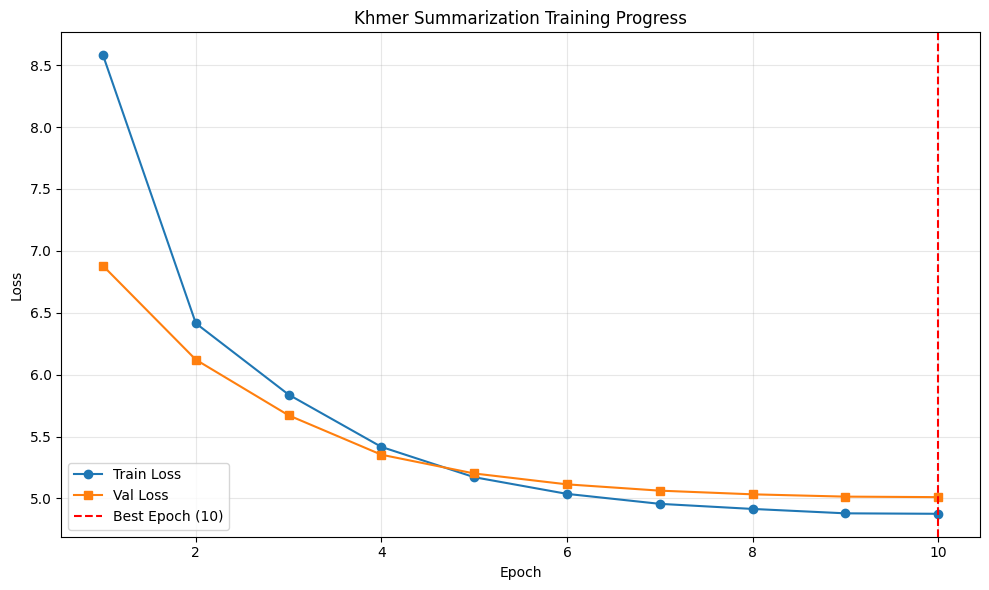

✓ Training curve saved to khmer_summarizer_output/training_curve.png


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history['epochs'], history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['epochs'], history['val_loss'], label='Val Loss', marker='s')
plt.axvline(x=history['best_epoch'], color='r', linestyle='--', label=f'Best Epoch ({history["best_epoch"]})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Khmer Summarization Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{config.OUTPUT_DIR}/training_curve.png", dpi=150)
plt.show()

print(f"✓ Training curve saved to {config.OUTPUT_DIR}/training_curve.png")

Load the best checkpoint for inference


In [16]:
print("Loading best model...")
checkpoint = torch.load(
    f"{config.OUTPUT_DIR}/best_model.pt", 
    map_location=device,
    weights_only=False  # ← Add this
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✓ Loaded best model from epoch {checkpoint['epoch'] + 1}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")

Loading best model...
✓ Loaded best model from epoch 10
  Val Loss: 5.0109


Generate summaries with configurable decoding strategies


In [17]:

# def generate_summaries(
#     model,
#     articles: List[str],
#     tokenizer: spm.SentencePieceProcessor,
#     max_length: int = 150,
#     min_length: int = 30,
#     num_beams: int = 5,
#     length_penalty: float = 1.0,
#     no_repeat_ngram_size: int = 3,
#     batch_size: int = 16,
#     max_source_len: int = None,   # allow override
# ):
#     model.eval()

#     pad_id = tokenizer.pad_id()
#     if pad_id < 0:
#         raise ValueError("SentencePiece tokenizer has no PAD token (pad_id=-1). Retrain with pad_id>=0.")

#     # ✅ device comes from model (safe after restart)
#     device = next(model.parameters()).device

#     if max_source_len is None:
#         max_source_len = config.MAX_SOURCE_LEN  # keep your existing config

#     all_summaries = []

#     with torch.inference_mode():
#         for i in tqdm(range(0, len(articles), batch_size), desc="Generating"):
#             batch_articles = articles[i:i + batch_size]

#             # Tokenize (truncate)
#             src_ids_list = [
#                 tokenizer.encode(a, out_type=int)[:max_source_len]
#                 for a in batch_articles
#             ]

#             # Pad
#             max_len = max(len(x) for x in src_ids_list)
#             src_ids_padded = [x + [pad_id] * (max_len - len(x)) for x in src_ids_list]
#             src_mask_padded = [[1] * len(x) + [0] * (max_len - len(x)) for x in src_ids_list]

#             src_ids = torch.tensor(src_ids_padded, dtype=torch.long, device=device)
#             src_mask = torch.tensor(src_mask_padded, dtype=torch.long, device=device)

#             # Generate
#             outputs = model.generate(
#                 src_ids,
#                 src_mask,
#                 tokenizer,
#                 max_length=max_length,
#                 min_length=min_length,
#                 num_beams=num_beams,
#                 length_penalty=length_penalty,
#                 no_repeat_ngram_size=no_repeat_ngram_size,
#             )

#             # Decode
#             bos, eos = tokenizer.bos_id(), tokenizer.eos_id()
#             for output_ids in outputs:
#                 # ensure list[int]
#                 if isinstance(output_ids, torch.Tensor):
#                     output_ids = output_ids.tolist()

#                 cleaned = [t for t in output_ids if t not in (bos, eos, pad_id)]
#                 all_summaries.append(tokenizer.decode(cleaned))

#     return all_summaries

@torch.no_grad()
def generate_summaries(
    model,
    articles: List[str],
    tokenizer: spm.SentencePieceProcessor,
    max_length: int = 150,
    min_length: int = 30,
    num_beams: int = 5,
    length_penalty: float = 1.0,
    no_repeat_ngram_size: int = 3,
    batch_size: int = 16,
):
    """Generate summaries for a list of articles"""
    model.eval()
    all_summaries = []
    
    # Process in batches
    for i in tqdm(range(0, len(articles), batch_size), desc="Generating"):
        batch_articles = articles[i:i + batch_size]
        
        # Tokenize
        src_ids_list = []
        for article in batch_articles:
            ids = tokenizer.encode(article, out_type=int)[:config.MAX_SOURCE_LEN]
            src_ids_list.append(ids)
        
        # Pad
        max_len = max(len(ids) for ids in src_ids_list)
        src_ids_padded = []
        src_mask_padded = []
        for ids in src_ids_list:
            padding = [tokenizer.pad_id()] * (max_len - len(ids))
            src_ids_padded.append(ids + padding)
            src_mask_padded.append([1] * len(ids) + [0] * len(padding))
        
        src_ids = torch.tensor(src_ids_padded, dtype=torch.long, device=device)
        src_mask = torch.tensor(src_mask_padded, dtype=torch.long, device=device)
        
        # Generate
        outputs = model.generate(
            src_ids,
            src_mask,
            tokenizer,
            max_length=max_length,
            min_length=min_length,
            num_beams=num_beams,
            length_penalty=length_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
        )
        
        # Decode
        for output_ids in outputs:
            # Remove BOS/EOS
            output_ids = [id for id in output_ids if id not in [tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.pad_id()]]
            summary = tokenizer.decode(output_ids)
            all_summaries.append(summary)
    
    return all_summaries

Implement chrF++, BERTScore, and ROUGE with proper Khmer handling


In [18]:
from sacrebleu.metrics import CHRF

# chrF++ metric
chrf_metric = CHRF(word_order=2)

def compute_chrf(predictions: List[str], references: List[str]) -> float:
    """Compute chrF++ score"""
    scores = []
    for pred, ref in zip(predictions, references):
        score = chrf_metric.sentence_score(pred, [ref])
        scores.append(score.score)
    return np.mean(scores)

# BERTScore
try:
    from bert_score import score as bert_score
    BERTSCORE_AVAILABLE = True
except:
    BERTSCORE_AVAILABLE = False
    print("⚠ BERTScore not available. Install: pip install bert-score")

def compute_bertscore(predictions: List[str], references: List[str]) -> Dict[str, float]:
    """Compute BERTScore using multilingual model"""
    if not BERTSCORE_AVAILABLE:
        return {'P': 0.0, 'R': 0.0, 'F1': 0.0}
    
    P, R, F1 = bert_score(
        predictions,
        references,
        lang='other',
        model_type='xlm-roberta-base',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        verbose=False
    )
    
    return {
        'P': P.mean().item(),
        'R': R.mean().item(),
        'F1': F1.mean().item(),
    }

# Custom metrics
def compute_length_stats(predictions: List[str], references: List[str], articles: List[str]) -> Dict[str, float]:
    """Compute length-related statistics"""
    pred_lens = [len(p) for p in predictions]
    ref_lens = [len(r) for r in references]
    article_lens = [len(a) for a in articles]
    
    compression_ratios = [pl / al if al > 0 else 0 for pl, al in zip(pred_lens, article_lens)]
    length_ratios = [pl / rl if rl > 0 else 0 for pl, rl in zip(pred_lens, ref_lens)]
    
    return {
        'avg_pred_len': np.mean(pred_lens),
        'avg_ref_len': np.mean(ref_lens),
        'avg_compression_ratio': np.mean(compression_ratios),
        'avg_length_ratio': np.mean(length_ratios),
    }

def compute_novelty(predictions: List[str], articles: List[str], n: int = 3) -> float:
    """Compute percentage of novel n-grams (not in source)"""
    novelty_scores = []
    
    for pred, article in zip(predictions, articles):
        # Extract character n-grams
        pred_ngrams = set(pred[i:i+n] for i in range(len(pred) - n + 1))
        article_ngrams = set(article[i:i+n] for i in range(len(article) - n + 1))
        
        if len(pred_ngrams) == 0:
            novelty_scores.append(0.0)
        else:
            novel = len(pred_ngrams - article_ngrams)
            novelty_scores.append(novel / len(pred_ngrams))
    
    return np.mean(novelty_scores)

# compute rouge score
def compute_rouge_khmer(prediction: str, reference: str) -> Dict[str, float]:
    """
    Compute ROUGE scores for Khmer (character-level n-grams)
    
    Standard ROUGE assumes whitespace tokenization → doesn't work for Khmer
    This uses character-level n-grams instead
    """
    def get_char_ngrams(text: str, n: int) -> set:
        """Extract character n-grams"""
        if len(text) < n:
            return set()
        return set(text[i:i+n] for i in range(len(text) - n + 1))
    
    def compute_f1(pred_ngrams: set, ref_ngrams: set) -> float:
        """Compute F1 score"""
        if not pred_ngrams or not ref_ngrams:
            return 0.0
        
        overlap = len(pred_ngrams & ref_ngrams)
        precision = overlap / len(pred_ngrams) if pred_ngrams else 0
        recall = overlap / len(ref_ngrams) if ref_ngrams else 0
        
        if precision + recall == 0:
            return 0.0
        return 2 * precision * recall / (precision + recall)
    
    # Character-level ROUGE-1, ROUGE-2, ROUGE-3
    rouge_1 = compute_f1(get_char_ngrams(prediction, 1), get_char_ngrams(reference, 1))
    rouge_2 = compute_f1(get_char_ngrams(prediction, 2), get_char_ngrams(reference, 2))
    rouge_3 = compute_f1(get_char_ngrams(prediction, 3), get_char_ngrams(reference, 3))
    
    # ROUGE-L: Longest common subsequence
    def lcs_length(s1: str, s2: str) -> int:
        """Dynamic programming LCS"""
        m, n = len(s1), len(s2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if s1[i-1] == s2[j-1]:
                    dp[i][j] = dp[i-1][j-1] + 1
                else:
                    dp[i][j] = max(dp[i-1][j], dp[i][j-1])
        return dp[m][n]
    
    lcs_len = lcs_length(prediction, reference)
    rouge_l_precision = lcs_len / len(prediction) if prediction else 0
    rouge_l_recall = lcs_len / len(reference) if reference else 0
    rouge_l = 2 * rouge_l_precision * rouge_l_recall / (rouge_l_precision + rouge_l_recall) if (rouge_l_precision + rouge_l_recall) > 0 else 0
    
    return {
        'rouge1': rouge_1 * 100,
        'rouge2': rouge_2 * 100,
        'rouge3': rouge_3 * 100,
        'rougeL': rouge_l * 100,
    }

Comprehensive evaluation with multiple metrics


In [20]:
print("=" * 60)
print("Running Evaluation on Test Set")
print("=" * 60)

# Select subset for faster evaluation during development
# For final evaluation, use full test set
eval_indices = list(range(min(50, len(test_dataset))))  # Adjust as needed
eval_articles = [test_dataset.articles[i] for i in eval_indices]
eval_references = [test_dataset.summaries[i] for i in eval_indices]

print(f"Evaluating on {len(eval_articles)} examples...")

# Generate summaries
print("\n1. Generating summaries...")
start_time = time.time()

# =======================================================
# Generate summaries
# =======================================================

# predictions = generate_summaries(
#     model,
#     eval_articles,
#     sp,
#     max_length=config.MAX_TARGET_LEN,
#     min_length=config.MIN_TARGET_LEN,
#     num_beams=config.NUM_BEAMS,
#     length_penalty=config.LENGTH_PENALTY,
#     no_repeat_ngram_size=config.NO_REPEAT_NGRAM,
#     batch_size=config.EVAL_BATCH_SIZE,
# )

# load summary instead of generating for faster testing. the save is in ./khmer_summarizer_output/test_prediction.csv
# the columns are article,reference_summary,generated_summary,article_length,reference_length,generated_length,chrf_score
import pandas as pd
pred_df = pd.read_csv(f"{config.OUTPUT_DIR}/test_predictions.csv")
predictions = pred_df['generated_summary'].tolist()


generation_time = time.time() - start_time
print(f"✓ Generated {len(predictions)} summaries in {generation_time:.1f}s ({generation_time/len(predictions):.2f}s per summary)")

# Compute metrics
print("\n2. Computing metrics...")

# chrF++
print("  - Computing chrF++...")
chrf_score = compute_chrf(predictions, eval_references)

# BERTScore
print("  - Computing BERTScore...")
bertscore_results = compute_bertscore(predictions, eval_references)

# Length statistics
print("  - Computing length statistics...")
length_stats = compute_length_stats(predictions, eval_references, eval_articles)

# Novelty
print("  - Computing novelty...")
novelty_3gram = compute_novelty(predictions, eval_articles, n=3)
novelty_5gram = compute_novelty(predictions, eval_articles, n=5)

# ROUGE
print("  - Computing ROUGE scores...")
rouge1_scores = []
rouge2_scores = []
rouge3_scores = []
rougeL_scores = []
for pred, ref in zip(predictions, eval_references):
    rouge_scores = compute_rouge_khmer(pred, ref)
    rouge1_scores.append(rouge_scores['rouge1'])
    rouge2_scores.append(rouge_scores['rouge2'])
    rouge3_scores.append(rouge_scores['rouge3'])
    rougeL_scores.append(rouge_scores['rougeL'])
    avg_rouge1 = np.mean(rouge1_scores)
    avg_rouge2 = np.mean(rouge2_scores)
    avg_rouge3 = np.mean(rouge3_scores)
    avg_rougeL = np.mean(rougeL_scores)


# Compile results
results = {
    'chrF++': chrf_score,
    'BERTScore_Precision': bertscore_results['P'],
    'BERTScore_Recall': bertscore_results['R'],
    'BERTScore_F1': bertscore_results['F1'],
    'avg_prediction_length': length_stats['avg_pred_len'],
    'avg_reference_length': length_stats['avg_ref_len'],
    'compression_ratio': length_stats['avg_compression_ratio'],
    'length_ratio': length_stats['avg_length_ratio'],
    'novelty_3gram': novelty_3gram,
    'novelty_5gram': novelty_5gram,
    'rouge1': rouge1_scores,
    'rouge2': rouge2_scores,
    'rouge3': rouge3_scores,
    'rougeL': rougeL_scores,
    'rouge1_avg': avg_rouge1,
    'rouge2_avg': avg_rouge2,
    'rouge3_avg': avg_rouge3,
    'rougeL_avg': avg_rougeL,
    'num_samples': len(predictions),
    'generation_time_per_sample': generation_time / len(predictions),
}

# Print results
print("\n" + "=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
print(f"\nAutomatic Metrics:")
print(f"  chrF++:              {results['chrF++']:.2f}")
print(f"  BERTScore Precision: {results['BERTScore_Precision']:.4f}")
print(f"  BERTScore Recall:    {results['BERTScore_Recall']:.4f}")
print(f"  BERTScore F1:        {results['BERTScore_F1']:.4f}")

print(f"\nLength Statistics:")
print(f"  Avg Prediction Length: {results['avg_prediction_length']:.1f} chars")
print(f"  Avg Reference Length:  {results['avg_reference_length']:.1f} chars")
print(f"  Compression Ratio:     {results['compression_ratio']:.2%}")
print(f"  Length Ratio (pred/ref): {results['length_ratio']:.2f}")

print(f"\nAbstractiveness:")
print(f"  Novel 3-grams: {results['novelty_3gram']:.2%}")
print(f"  Novel 5-grams: {results['novelty_5gram']:.2%}")

print(f"\nROUGE Scores (character-level):")
print(f"  ROUGE-1: {results['rouge1_avg']:.2f}")
print(f"  ROUGE-2: {results['rouge2_avg']:.2f}")
print(f"  ROUGE-3: {results['rouge3_avg']:.2f}")
print(f"  ROUGE-L: {results['rougeL_avg']:.2f}")

print(f"\nPerformance:")
print(f"  Generation Time: {results['generation_time_per_sample']:.2f}s per sample")

# Save results
with open(f"{config.OUTPUT_DIR}/evaluation_results.json", 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"\n✓ Results saved to {config.OUTPUT_DIR}/evaluation_results.json")

Running Evaluation on Test Set
Evaluating on 50 examples...

1. Generating summaries...
✓ Generated 50 summaries in 0.0s (0.00s per summary)

2. Computing metrics...
  - Computing chrF++...
  - Computing BERTScore...
  - Computing length statistics...
  - Computing novelty...
  - Computing ROUGE scores...

EVALUATION RESULTS

Automatic Metrics:
  chrF++:              11.32
  BERTScore Precision: 0.7733
  BERTScore Recall:    0.7819
  BERTScore F1:        0.7774

Length Statistics:
  Avg Prediction Length: 252.0 chars
  Avg Reference Length:  87.7 chars
  Compression Ratio:     20.75%
  Length Ratio (pred/ref): 3.42

Abstractiveness:
  Novel 3-grams: 58.01%
  Novel 5-grams: 84.33%

ROUGE Scores (character-level):
  ROUGE-1: 59.63
  ROUGE-2: 24.31
  ROUGE-3: 11.19
  ROUGE-L: 24.53

Performance:
  Generation Time: 0.00s per sample

✓ Results saved to khmer_summarizer_output/evaluation_results.json


Display sample predictions for manual inspection


In [21]:
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

# Show 5 random samples
sample_indices = np.random.choice(len(predictions), min(5, len(predictions)), replace=False)

for idx, sample_idx in enumerate(sample_indices):
    print(f"\n{'='*60}")
    print(f"Sample {idx + 1}")
    print(f"{'='*60}")
    
    print(f"\n[ARTICLE] ({len(eval_articles[sample_idx])} chars):")
    print(eval_articles[sample_idx][:300] + "..." if len(eval_articles[sample_idx]) > 300 else eval_articles[sample_idx])
    
    print(f"\n[REFERENCE SUMMARY] ({len(eval_references[sample_idx])} chars):")
    print(eval_references[sample_idx])
    
    print(f"\n[GENERATED SUMMARY] ({len(predictions[sample_idx])} chars):")
    print(predictions[sample_idx])
    
    # Compute metrics for this sample
    sample_chrf = chrf_metric.sentence_score(predictions[sample_idx], [eval_references[sample_idx]]).score
    print(f"\n[METRICS]:")
    print(f"  chrF++: {sample_chrf:.2f}")
    print(f"  Length ratio: {len(predictions[sample_idx]) / len(eval_references[sample_idx]):.2f}")


SAMPLE PREDICTIONS

Sample 1

[ARTICLE] (2468 chars):
​គម្រោង​ធ្វើ​ឱ្យ​ប្រសើរ​ឡើង​នូវ​ផ្លូវ​តភ្ជាប់​ខេត្ត​ Qu​an​g​ N​am​ ​ទៅកាន់​តំបន់​ខ្ពង់រាប​កណ្តាល​ ​និង​ប្រទេសជិតខាង​ត្រូវ​បាន​ចាប់ផ្តើម​កាលពី​ថ្ងៃអង្គារ​ដោយ​ក្រសួង​ដឹកជញ្ជូន​ ​និង​គណៈកម្មាធិការ​ប្រជាជន​ខេត្ត​។​
​ផ្លូវជាតិ​លេខ​ 14​E​ ​ដែល​មាន​ប្រវែង​៩​០​ ​គីឡូម៉ែត្រ​ ​តភ្ជាប់​ពី​ភាគ​ខាងកើត​ ​និង​ខាង...

[REFERENCE SUMMARY] (150 chars):
​វៀតណាម​ដាក់​ដំណើរការ​គម្រោង​ផ្លូវ​មួយ​ខ្សែ​ដែល​មាន​តម្លៃ​ ​៧​៦​ ​លាន​ដុល្លារ​សម្រាប់​តភ្ជាប់​ខេត្ត​ Qu​an​g​ N​am​ ​ទៅ​ប្រទេស​កម្ពុជា​ ​ឡាវ​ ​និង​ថៃ​

[GENERATED SUMMARY] (340 chars):
​ក្រសួង​ ​និង​ ​កម្ពុជា​កម្ពុជា​ ​១​ ​ការ​ ​២​ ​នៅ​ ​នឹង​ ​បាន​ ​ក្នុង​ ​ដើម្បី​ ​​ ​ឆ្នាំ​ ​ ​កម្ពុជា​-​១ ​និង​-​១​-​១​កម្ពុជា​-​ ​១​-​ ​២ ​និង ​១ ​១​ ​និង​០​ ​នាក់​ ​ចំនួន​ ​ពី​ ​៣​ ​ខេត្ត​ ​៧​ ​ដែល​ ​លើ​ ​ប្រទេស​ ​ត្រូវ​ ​៥​ ​សម្រាប់​ ​ដល់​ ​របស់​ ​ក្រសួង​-​១​,​ ​២​-​ ​ក្នុង​-​ ​ ​នៅ​-​ ​កម្ពុជា ​និង​ ​និង ​និង និង​ ​ហ៊ុន​ ​ថ្មី​ ​លាន​

[METRICS]:
  chrF++: 21.89
  Length ratio: 2.27

Sample 2

[ARTICLE] (2886 chars

Identify common failure modes


In [22]:
print("\n" + "=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

# Find examples with different characteristics
def categorize_predictions(predictions, references, articles):
    categories = {
        'empty': [],
        'too_short': [],
        'too_long': [],
        'repetitive': [],
        'low_quality': [],
    }
    
    for i, (pred, ref, article) in enumerate(zip(predictions, references, articles)):
        # Empty or very short
        if len(pred) < 20:
            categories['empty'].append(i)
        
        # Too short (< 50% of reference)
        elif len(pred) < len(ref) * 0.5:
            categories['too_short'].append(i)
        
        # Too long (> 150% of reference)
        elif len(pred) > len(ref) * 1.5:
            categories['too_long'].append(i)
        
        # Repetitive (check for repeated 3-grams)
        trigrams = [pred[i:i+3] for i in range(len(pred) - 2)]
        if len(trigrams) > 0 and len(set(trigrams)) / len(trigrams) < 0.5:
            categories['repetitive'].append(i)
        
        # Low chrF score
        score = chrf_metric.sentence_score(pred, [ref]).score
        if score < 20:
            categories['low_quality'].append(i)
    
    return categories

error_categories = categorize_predictions(predictions, eval_references, eval_articles)

print("\nError Category Counts:")
for category, indices in error_categories.items():
    print(f"  {category:15s}: {len(indices):4d} ({len(indices)/len(predictions)*100:5.2f}%)")

# Show one example from each non-empty category
print("\n" + "=" * 60)
print("EXAMPLE ERRORS")
print("=" * 60)

for category, indices in error_categories.items():
    if len(indices) > 0:
        idx = indices[0]
        print(f"\n{'-'*60}")
        print(f"Category: {category.upper()}")
        print(f"{'-'*60}")
        print(f"\nArticle: {eval_articles[idx][:200]}...")
        print(f"\nReference: {eval_references[idx]}")
        print(f"\nPrediction: {predictions[idx]}")
        print(f"\nLength: pred={len(predictions[idx])}, ref={len(eval_references[idx])}")


ERROR ANALYSIS

Error Category Counts:
  empty          :    0 ( 0.00%)
  too_short      :    2 ( 4.00%)
  too_long       :   37 (74.00%)
  repetitive     :   28 (56.00%)
  low_quality    :   48 (96.00%)

EXAMPLE ERRORS

------------------------------------------------------------
Category: TOO_SHORT
------------------------------------------------------------

Article: ​ខណៈ​ដែល​បញ្ញា​សិប្បនិម្មិត​ (​A​I​) ​កាន់តែ​មាន​ភាព​ជឿនលឿន​ ​វា​បាន​ជះ​ឥទ្ធិពល​យ៉ាង​ធំធេង​ទៅលើ​ការស្រាវជ្រាវ​ ​និង​អភិវឌ្ឍន៍​ (R&​D​)​។​ ​យើង​មិន​មាន​ព័ត៌មាន​ច្រើន​អំពី​របៀប​ដែល​រដ្ឋាភិបាល​នឹង​ពន្លឿន...

Reference: ​របាយការណ៍​ថ្មី​បាន​បង្ហាញ​ពី​យុទ្ធសាស្ត្រ​សកល​សម្រាប់​បង្កើន​ការប្រើប្រាស់​បញ្ញា​សិប្បនិម្មិត​ក្នុង​វិ​ស័​យ​វិទ្យាសាស្ត្រ​ ​និង​ស្រាវជ្រាវ​

Prediction: ​ក្រសួង​ ​និង​ ​កម្ពុជា​កម្ពុជា​ ​១​ ​ការ​ ​នៅ​ ​នឹង​ ​ក្នុង​ ​២​ ​

Length: pred=67, ref=140

------------------------------------------------------------
Category: TOO_LONG
------------------------------------------------------------

Article: ​ខេត្ត​បាត

Save predictions for further analysis or human evaluation

In [23]:
# Create detailed output DataFrame
output_df = pd.DataFrame({
    'article': eval_articles,
    'reference_summary': eval_references,
    'generated_summary': predictions,
    'article_length': [len(a) for a in eval_articles],
    'reference_length': [len(r) for r in eval_references],
    'generated_length': [len(p) for p in predictions],
    'chrf_score': [chrf_metric.sentence_score(p, [r]).score for p, r in zip(predictions, eval_references)],
})

# Save to CSV
output_path = f"{config.OUTPUT_DIR}/test_predictions.csv"
output_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n✓ Saved {len(output_df)} predictions to {output_path}")

# Save a sample for human evaluation
sample_size = min(100, len(output_df))
sample_df = output_df.sample(n=sample_size, random_state=config.SEED)
sample_path = f"{config.OUTPUT_DIR}/human_eval_sample_{sample_size}.csv"
sample_df.to_csv(sample_path, index=False, encoding='utf-8-sig')
print(f"✓ Saved {sample_size} random samples for human evaluation to {sample_path}")


✓ Saved 50 predictions to khmer_summarizer_output/test_predictions.csv
✓ Saved 50 random samples for human evaluation to khmer_summarizer_output/human_eval_sample_50.csv


Save model and tokenizer for deployment


In [24]:
print("\n" + "=" * 60)
print("EXPORTING MODEL FOR PRODUCTION")
print("=" * 60)

# Save model in production-ready format
export_dir = f"{config.OUTPUT_DIR}/production_model"
Path(export_dir).mkdir(parents=True, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), f"{export_dir}/model_weights.pt")
print(f"✓ Saved model weights")

# Save config
config_dict = {k: v for k, v in vars(config).items() if not k.startswith('_')}
with open(f"{export_dir}/config.json", 'w') as f:
    json.dump(config_dict, f, indent=2)
print(f"✓ Saved configuration")

# Copy tokenizer files
import shutil
shutil.copy(f"{config.TOKENIZER_PATH}.model", f"{export_dir}/tokenizer.model")
shutil.copy(f"{config.TOKENIZER_PATH}.vocab", f"{export_dir}/tokenizer.vocab")
print(f"✓ Copied tokenizer files")


EXPORTING MODEL FOR PRODUCTION
✓ Saved model weights
✓ Saved configuration
✓ Copied tokenizer files


In [25]:
# Create inference script template
inference_script = '''#!/usr/bin/env python3
"""
Production inference script for Khmer summarization
"""
import torch
import sentencepiece as spm
import json
from pathlib import Path

# Load configuration
with open('config.json', 'r') as f:
    config = json.load(f)

# Load tokenizer
sp = spm.SentencePieceProcessor()
sp.load('tokenizer.model')

# Load model
# TODO: Import model class definition
# model = PointerGeneratorSummarizer(config, sp.get_piece_size(), sp.pad_id())
# model.load_state_dict(torch.load('model_weights.pt', map_location='cpu'))
# model.eval()

def summarize(article: str) -> str:
    """Generate summary for input article"""
    # Implement inference logic here
    pass

if __name__ == '__main__':
    article = "Your Khmer article here..."
    summary = summarize(article)
    print(f"Summary: {summary}")
'''

with open(f"{export_dir}/inference.py", 'w') as f:
    f.write(inference_script)
print(f"✓ Created inference script template")

print(f"\n✓ Production model exported to: {export_dir}")

✓ Created inference script template

✓ Production model exported to: khmer_summarizer_output/production_model


Generate comprehensive report


In [26]:
# load training history from ./khmer_summarization_output/training_history.json
with open(f"{config.OUTPUT_DIR}/training_history.json", 'r') as f:
    history = json.load(f)

report = f"""
{'='*80}
KHMER ABSTRACTIVE SUMMARIZATION - FINAL REPORT
{'='*80}

DATASET INFORMATION
{'-'*80}
Total samples:        {len(df)}
Train samples:        {len(train_df)}
Validation samples:   {len(val_df)}
Test samples:         {len(test_df)}
Evaluated samples:    {len(predictions)}

MODEL ARCHITECTURE
{'-'*80}
Encoder:              {config.ENCODER_MODEL}
Decoder layers:       {config.DECODER_LAYERS}
Attention heads:      {config.DECODER_HEADS}
Hidden size:          {config.HIDDEN_SIZE}
Total parameters:     {total_params:,}
Trainable parameters: {trainable_params:,}
Pointer-generator:    {'Enabled' if config.USE_POINTER else 'Disabled'}

TRAINING CONFIGURATION
{'-'*80}
Epochs:               {config.NUM_EPOCHS}
Batch size:           {config.BATCH_SIZE}
Gradient accum:       {config.GRAD_ACCUMULATION}
Learning rate:        {config.LEARNING_RATE}
Encoder LR:           {config.ENCODER_LR}
Warmup ratio:         {config.WARMUP_RATIO}
Mixed precision:      {'Enabled (FP16)' if config.FP16 else 'Disabled'}

TRAINING RESULTS
{'-'*80}
Best epoch:           {history['best_epoch']}
Best val loss:        {history['best_val_loss']:.4f}
Final train loss:     {history['train_loss'][-1]:.4f}
Final val loss:       {history['val_loss'][-1]:.4f}

EVALUATION RESULTS
{'-'*80}
chrF++:               {results['chrF++']:.2f}
BERTScore F1:         {results['BERTScore_F1']:.4f}
BERTScore Precision:  {results['BERTScore_Precision']:.4f}
BERTScore Recall:     {results['BERTScore_Recall']:.4f}

Avg pred length:      {results['avg_prediction_length']:.1f} chars
Avg ref length:       {results['avg_reference_length']:.1f} chars
Compression ratio:    {results['compression_ratio']:.2%}
Length ratio:         {results['length_ratio']:.2f}

Novel 3-grams:        {results['novelty_3gram']:.2%}
Novel 5-grams:        {results['novelty_5gram']:.2%}

ROUGE SCORES:
{'-'*80}

ROUGE-1 average:      {results['rouge1_avg']:.2f}
ROUGE-2 average:      {results['rouge2_avg']:.2f}
ROUGE-3 average:      {results['rouge3_avg']:.2f}
ROUGE-L average:      {results['rougeL_avg']:.2f}

Generation time:      {results['generation_time_per_sample']:.2f}s per sample

ERROR ANALYSIS
{'-'*80}
Empty outputs:        {len(error_categories['empty'])} ({len(error_categories['empty'])/len(predictions)*100:.1f}%)
Too short:            {len(error_categories['too_short'])} ({len(error_categories['too_short'])/len(predictions)*100:.1f}%)
Too long:             {len(error_categories['too_long'])} ({len(error_categories['too_long'])/len(predictions)*100:.1f}%)
Repetitive:           {len(error_categories['repetitive'])} ({len(error_categories['repetitive'])/len(predictions)*100:.1f}%)
Low quality:          {len(error_categories['low_quality'])} ({len(error_categories['low_quality'])/len(predictions)*100:.1f}%)

OUTPUT FILES
{'-'*80}
Model checkpoint:     {config.OUTPUT_DIR}/best_model.pt
Training history:     {config.OUTPUT_DIR}/training_history.json
Evaluation results:   {config.OUTPUT_DIR}/evaluation_results.json
Test predictions:     {config.OUTPUT_DIR}/test_predictions.csv
Human eval sample:    {config.OUTPUT_DIR}/human_eval_sample_{sample_size}.csv
Production model:     {config.OUTPUT_DIR}/production_model/
Training curve:       {config.OUTPUT_DIR}/training_curve.png

{'='*80}
"""

print(report)

# Save report
with open(f"{config.OUTPUT_DIR}/final_report.txt", 'w', encoding='utf-8') as f:
    f.write(report)
print(f"✓ Final report saved to {config.OUTPUT_DIR}/final_report.txt")

print("\n" + "="*80)
print("ALL TRAINING AND EVALUATION COMPLETE!")
print("="*80)


KHMER ABSTRACTIVE SUMMARIZATION - FINAL REPORT

DATASET INFORMATION
--------------------------------------------------------------------------------
Total samples:        12850
Train samples:        10280
Validation samples:   1285
Test samples:         1285
Evaluated samples:    50

MODEL ARCHITECTURE
--------------------------------------------------------------------------------
Encoder:              xlm-roberta-base
Decoder layers:       6
Attention heads:      12
Hidden size:          768
Total parameters:     384,061,184
Trainable parameters: 384,061,184
Pointer-generator:    Disabled

TRAINING CONFIGURATION
--------------------------------------------------------------------------------
Epochs:               10
Batch size:           12
Gradient accum:       4
Learning rate:        5e-06
Encoder LR:           1e-06
Warmup ratio:         0.3
Mixed precision:      Enabled (FP16)

TRAINING RESULTS
--------------------------------------------------------------------------------
Best